# Load USGS variometer station locations on a map

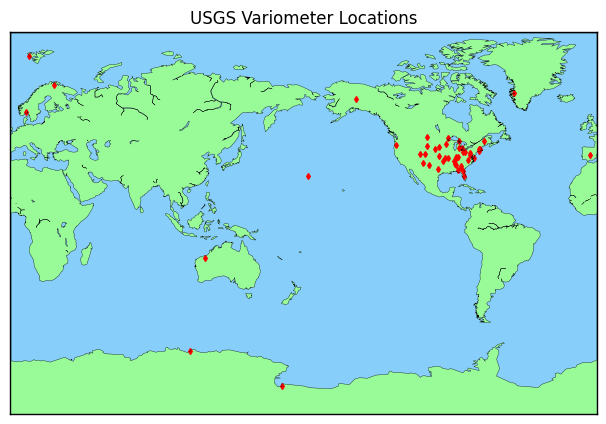

In [1]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(8,4.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

# mercator/2D map 
tmap = tplot_map(llcrnrlon=0,llcrnrlat=-85,urcrnrlon=360,urcrnrlat=85,projection='mill')
tmap._params.drawmapboundary = {"fill_color":"lightskyblue"}
tmap._params.fillcontinents = {"color":"palegreen","lake_color":"lightskyblue"}

# Add ground station markers
themis_gmag_dict = gmag.Themis_gmag()
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=3)

tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#date_str = '2026-02-03'
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 15:00:00",'%Y-%m-%d %H:%M:%S'))
plt.title("USGS Variometer Locations")
#ax.legend()
plt.show()

# Plot trace footpaths alongside variometer station markers 

Import packages:

In [2]:
from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, tplot_trace_tvars_to_tmap, add_markers, add_station_fovs, tvar_to_foottracks, add_tracks
from pyspedas.projects.themis import state
from pyspedas.projects.themis.ground import gmag
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

Create tplot variables THEMIS A and THEMIS D positional data:

In [3]:
date_str = '2026-01-20'
time_range = [date_str,date_str]
state(trange=time_range, probe='a')
state(trange=time_range, probe='d')

26-Jun-26 16:38:38: File is current: themis_data/tha/l1/state/2026/tha_l1_state_20260120.cdf
26-Jun-26 16:38:39: File is current: themis_data/thd/l1/state/2026/thd_l1_state_20260120.cdf


['thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse']

Compute traces:

In [4]:
trace_a = tvar_to_foottracks(tvar_to_trace = 'tha_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")
trace_d = tvar_to_foottracks(tvar_to_trace = 'thd_pos_gsm', model_str = "t89", endpoint = "ionosphere-north")

26-Jun-26 16:38:39: The km parameter is deprecated. Please use units_in, foot_out_units, and trace_out_units instead.
26-Jun-26 16:38:39: Setting units_in, foot_out_units, and trace_out_units to 'km'.
26-Jun-26 16:38:39: Setting units for input_var_re
26-Jun-26 16:38:39: get_t89_parameters: No kp, iopt, or parmod data provided, defaulting to iopt=3


Load IGRF coefficients ...


26-Jun-26 16:38:44: Computed 100/1440 traces so far, current trace time 2026-01-20 01:40:00.000000
26-Jun-26 16:38:47: Computed 200/1440 traces so far, current trace time 2026-01-20 03:20:00.000000
26-Jun-26 16:38:50: Computed 300/1440 traces so far, current trace time 2026-01-20 05:00:00.000000
26-Jun-26 16:38:52: Computed 400/1440 traces so far, current trace time 2026-01-20 06:40:00.000000
26-Jun-26 16:38:55: Computed 500/1440 traces so far, current trace time 2026-01-20 08:20:00.000000
26-Jun-26 16:38:59: Computed 600/1440 traces so far, current trace time 2026-01-20 10:00:00.000000
26-Jun-26 16:39:05: Computed 700/1440 traces so far, current trace time 2026-01-20 11:40:00.000000
26-Jun-26 16:39:13: Computed 800/1440 traces so far, current trace time 2026-01-20 13:20:00.000000
26-Jun-26 16:39:22: Computed 900/1440 traces so far, current trace time 2026-01-20 15:00:00.000000
26-Jun-26 16:39:32: Computed 1000/1440 traces so far, current trace time 2026-01-20 16:40:00.000000
26-Jun-26

Initialize THEMIS GMAG dictionary:

In [5]:
themis_gmag_dict = gmag.Themis_gmag()

Determine which variometer stations are closest to the THEMIS A,D footpaths:

In [6]:
def vpolar_to_vcartesian(theta,phi):
    return (np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta))

def ang_sep(station_dict:dict,trace_data):
    s_theta = np.deg2rad(90.0-float(station_dict['lat']))
    s_phi = np.deg2rad(float(station_dict['lng']))
    s_x, s_y, s_z = vpolar_to_vcartesian(s_theta,s_phi)
    
    t_theta = np.deg2rad(90.0 - trace_data[:,1])
    t_phi = np.deg2rad(trace_data[:,2])
    t_x, t_y, t_z = vpolar_to_vcartesian(t_theta,t_phi)
    
    ang_sep_arr = np.rad2deg( np.arccos( (s_x*t_x)+(s_y*t_y)+(s_z*t_z) ) )
    return ang_sep_arr

variom_dist_list = []
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        ang_sep_a = ang_sep(station_dict=station_dict,trace_data=trace_a[0])
        ang_sep_d = ang_sep(station_dict=station_dict,trace_data=trace_d[0])
        dist_tuple = (station_dict['ccode'],np.min(ang_sep_a),np.min(ang_sep_d))
        variom_dist_list.append(dist_tuple)

num_listed = 5

print("Top " + str(num_listed) + " closest stations to THEMIS A:")
variom_dist_list.sort(key=lambda distance: distance[1])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[1]) 
#print(variom_dist_list)

print("Top " + str(num_listed) + " closest stations to THEMIS D:")
variom_dist_list.sort(key=lambda distance: distance[2])
for entry in variom_dist_list[0:num_listed]:
    print("Station: " + entry[0] + "; angular separation: %.2f degrees" % entry[2])

Top 5 closest stations to THEMIS A:
Station: KEVO; angular separation: 0.83 degrees
Station: COLA; angular separation: 1.82 degrees
Station: KONO; angular separation: 8.85 degrees
Station: KBS; angular separation: 9.00 degrees
Station: SFJD; angular separation: 9.13 degrees
Top 5 closest stations to THEMIS D:
Station: KEVO; angular separation: 0.05 degrees
Station: SFJD; angular separation: 6.76 degrees
Station: COLA; angular separation: 6.83 degrees
Station: PAB; angular separation: 7.66 degrees
Station: KONO; angular separation: 8.75 degrees


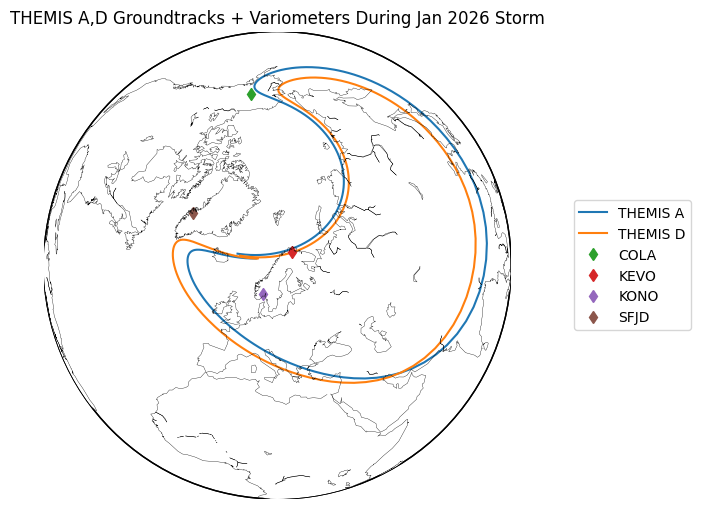

In [7]:
fig=plt.figure(figsize=(8,5.5))
ax = fig.add_axes([0.05,0.05,0.9,0.85])

mean_lat_a = np.mean((trace_a[0])[:,1])
mean_lon_a = np.mean((trace_a[0])[:,2])
mean_lat_d = np.mean((trace_d[0])[:,1])
mean_lon_d = np.mean((trace_d[0])[:,2])

mean_lat = np.mean([mean_lat_a,mean_lat_d])
mean_lon = np.mean([mean_lon_a,mean_lon_d])

# Initialize map:
#tmap = tplot_map(lat_0=50,lon_0=80)
tmap = tplot_map(lat_0=mean_lat,lon_0=mean_lon)

tmap._params.add_marker = {"linestyle":"","marker":"d"}

# Add ground tracks:
tmap = add_tracks(tmap=tmap, coords=trace_a[0], label = 'THEMIS A')
tmap = add_tracks(tmap=tmap, coords=trace_d[0], label = 'THEMIS D')

station_location_dict = {}

# Add ground station markers
for station_dict in themis_gmag_dict.get_gmag_list():
    if station_dict['variom'] == 'Y':
        if station_dict['ccode'] in ["KEVO","COLA","KONO","SFJD"]:
            station_location_dict[station_dict['ccode']] = {"lat":float(station_dict['lat']),"lng":float(station_dict['lng'])}
            tmap = add_markers(coords=np.array([0,float(station_dict['lat']),float(station_dict['lng'])]),tmap=tmap,label=station_dict['ccode'],ms=6)
        
tmap.add_map_boundary()
tmap.add_fillcontinents()
tmap.add_coastlines(linewidth=0.25)
#tmap.add_nightshade(date=dt.datetime.strptime(date_str+" 12:00:00",'%Y-%m-%d %H:%M:%S'))

plt.title("THEMIS A,D Groundtracks + Variometers During Jan 2026 Storm")
ax.legend(loc="center right",bbox_to_anchor=(1, 0, 0.4, 1))
plt.show()

Download THEMIS A,D FGM data and KEVO, COLA magnetic field data for the date of the geomagnetic storm:

In [8]:
from pyspedas.projects.themis.spacecraft.fields.fit import fit
from pyspedas.tplot_tools.tplot_names import tplot_names
from pyspedas import subtract_median
fit(trange=time_range,probe='a',get_support_data=True)
fit(trange=time_range,probe='d',get_support_data=True)
gmag.gmag(trange=time_range,sites=["kevo","cola"])
subtract_median(['thg_mag_kevo', 'thg_mag_cola'])
# tplot_names()

26-Jun-26 16:41:32: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fit/2026/
26-Jun-26 16:41:34: File is current: themis_data/tha/l2/fit/2026/tha_l2_fit_20260120_v01.cdf
26-Jun-26 16:41:34: Unable to get ydata for variable tha_fgs_sigma
26-Jun-26 16:41:34: Variable tha_fgs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
26-Jun-26 16:41:34: Variable tha_efs_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
26-Jun-26 16:41:34: Variable tha_fit_bfit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
26-Jun-26 16:41:34: Variable tha_fit_efit_time is marked as record-varying, but no DEPEND_TIME or DEPEND_0 attributes found. Treating as non-record-varying.
26-Jun-26 16:41:34: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thd/l2/fit/2026/
26-Jun-2

['thg_mag_kevo-m', 'thg_mag_cola-m']

In [26]:
tplot_names()

0 : tha_pos
1 : tha_vel
2 : tha_spin_initial_delta_phi
3 : tha_spin_idpu_spinper
4 : tha_spin_segflags
5 : tha_spin_ecl_initial_delta_phi
6 : tha_spin_ecl_idpu_spinper
7 : tha_spin_ecl_segflags
8 : tha_pos_gse
9 : tha_pos_gsm
10 : tha_vel_gse
11 : tha_vel_gsm
12 : tha_pos_sel
13 : tha_pos_sse
14 : tha_vel_sel
15 : tha_vel_sse
16 : thd_pos
17 : thd_vel
18 : thd_spin_initial_delta_phi
19 : thd_spin_idpu_spinper
20 : thd_spin_segflags
21 : thd_spin_ecl_initial_delta_phi
22 : thd_spin_ecl_idpu_spinper
23 : thd_spin_ecl_segflags
24 : thd_pos_gse
25 : thd_pos_gsm
26 : thd_vel_gse
27 : thd_vel_gsm
28 : thd_pos_sel
29 : thd_pos_sse
30 : thd_vel_sel
31 : thd_vel_sse
32 : input_var_re
33 : tha_pos_gsm_trace_iono_n_t89
34 : tha_pos_gsmt89ifoot_n
35 : thd_pos_gsm_trace_iono_n_t89
36 : thd_pos_gsmt89ifoot_n
37 : tha_fgs_dsl
38 : tha_fgs_gse
39 : tha_fgs_gsm
40 : tha_fgs_time
41 : tha_fgs_epoch0
42 : tha_efs_epoch0
43 : tha_fit_bfit_epoch0
44 : tha_fit_efit_epoch0
45 : range_epoch
46 : thd_fgs_sigma

['tha_pos',
 'tha_vel',
 'tha_spin_initial_delta_phi',
 'tha_spin_idpu_spinper',
 'tha_spin_segflags',
 'tha_spin_ecl_initial_delta_phi',
 'tha_spin_ecl_idpu_spinper',
 'tha_spin_ecl_segflags',
 'tha_pos_gse',
 'tha_pos_gsm',
 'tha_vel_gse',
 'tha_vel_gsm',
 'tha_pos_sel',
 'tha_pos_sse',
 'tha_vel_sel',
 'tha_vel_sse',
 'thd_pos',
 'thd_vel',
 'thd_spin_initial_delta_phi',
 'thd_spin_idpu_spinper',
 'thd_spin_segflags',
 'thd_spin_ecl_initial_delta_phi',
 'thd_spin_ecl_idpu_spinper',
 'thd_spin_ecl_segflags',
 'thd_pos_gse',
 'thd_pos_gsm',
 'thd_vel_gse',
 'thd_vel_gsm',
 'thd_pos_sel',
 'thd_pos_sse',
 'thd_vel_sel',
 'thd_vel_sse',
 'input_var_re',
 'tha_pos_gsm_trace_iono_n_t89',
 'tha_pos_gsmt89ifoot_n',
 'thd_pos_gsm_trace_iono_n_t89',
 'thd_pos_gsmt89ifoot_n',
 'tha_fgs_dsl',
 'tha_fgs_gse',
 'tha_fgs_gsm',
 'tha_fgs_time',
 'tha_fgs_epoch0',
 'tha_efs_epoch0',
 'tha_fit_bfit_epoch0',
 'tha_fit_efit_epoch0',
 'range_epoch',
 'thd_fgs_sigma',
 'thd_fgs_dsl',
 'thd_fgs_gse',
 'th

Plot magnetic field measurements for THEMIS A, D, COLA, and KEVO in the same time period:

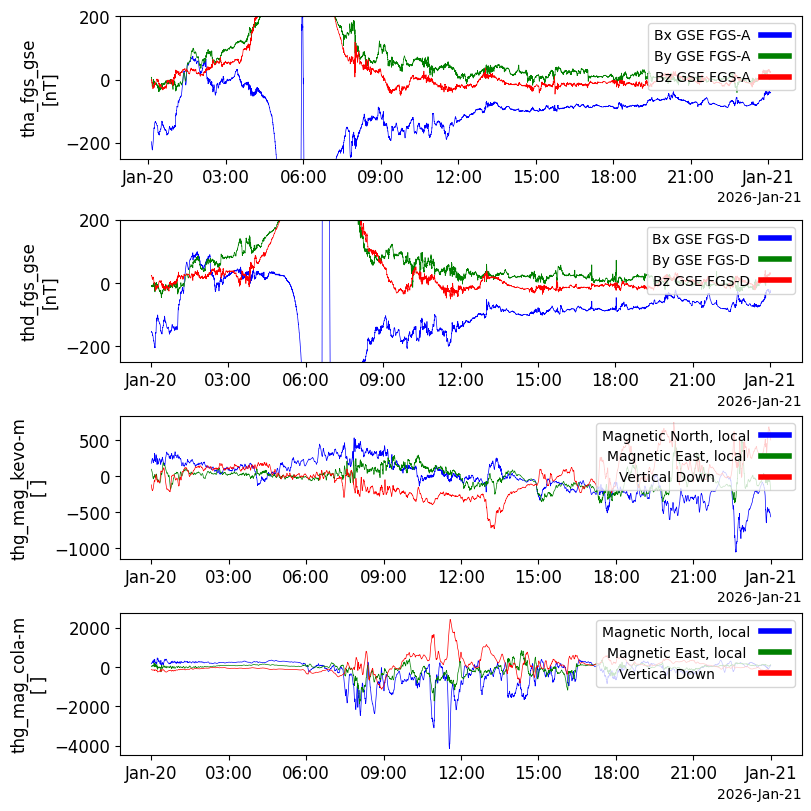

26-Jun-26 17:54:25: C:\Users\DC\AppData\Local\Temp\ipykernel_29516\289193181.py:40: UserWarning: The figure layout has changed to tight
  fig.tight_layout()



axs 3 x limits
(np.float64(20472.950000578705), np.float64(20474.049987847222))


In [56]:
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
from pyspedas.tplot_tools.get_data import get_data

def data_gradient(ax,data,**kwargs):
    """
    Applies gradient based on the value of provided 1D data
    """
    
    im = ax.imshow(data, **kwargs) #,clim=(0,1), aspect='auto'
    return im

def gradient_image(ax, direction=0.3, cmap_range=(0, 1), **kwargs):
    
    phi = direction * np.pi / 2
    v = np.array([np.cos(phi), np.sin(phi)])
    X = np.array([[v @ [1, 0], v @ [1, 1]],
                  [v @ [0, 0], v @ [0, 1]]])
    a, b = cmap_range
    X = a + (b - a) / X.max() * X
    im = ax.imshow(X, interpolation='bicubic', clim=(0, 1), aspect='auto', **kwargs)
    return im

fig, axs = plt.subplots(4,layout="constrained",figsize=(8,8))
# 'tha_fgs_btotal', 
axs[0].set_ylim(bottom=-250,top=200)
axs[1].set_ylim(bottom=-250,top=200)
#axs[3].legend(loc="center right", bbox_to_anchor=(1, 0, 1, 1))

ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a[0])
t = np.linspace((axs[3].get_xlim())[0],(axs[3].get_xlim())[1],len(ang_sep_kevo_a))
ys = np.linspace((axs[3].get_ylim())[0],(axs[3].get_ylim())[1],100)
#ang_sep_kevo_a_stacked = np.repeat(ang_sep_kevo_a,len(ys))
#data_gradient(axs[3],data=np.vstack((t,ang_sep_kevo_a)), cmap="Blues_r", alpha=0.5, extent=(20473,20474.5,-4000,2000))#, extent=(20473,20474.5,-4000,2000),cmap="Blues_r", cmap_range=(0.2, 0.8), alpha=0.5

#gradient_image(axs[3], direction=1, extent=(20473,20474.5,-4000,2000),cmap="Blues_r", cmap_range=(0.2, 0.8), alpha=0.5)

tplot(['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo-m','thg_mag_cola-m'],fig=fig,axis=axs)

#gradient_image(axs[2], extent=((axs[3].get_xlim())[0],(axs[3].get_xlim())[1],(axs[3].get_ylim())[0],(axs[3].get_ylim())[1]),cmap="Blues_r", cmap_range=(0, 0.8))
fig.tight_layout()

print("axs 3 x limits")
print(axs[3].get_xlim())

In [44]:
print(get_data("tha_pos_gsm").times)
print(get_data('thg_mag_kevo-m').y.min())
print(get_data('thg_mag_kevo-m').y.max())
#help(get_data('thg_mag_kevo-m'))

get_data('thg_mag_kevo-m').times

[1.76886720e+09 1.76886726e+09 1.76886732e+09 ... 1.76895342e+09
 1.76895348e+09 1.76895354e+09]
-1054.3252
745.4219


array([1.7688672e+09, 1.7688672e+09, 1.7688672e+09, ..., 1.7689536e+09,
       1.7689536e+09, 1.7689536e+09], shape=(86400,))

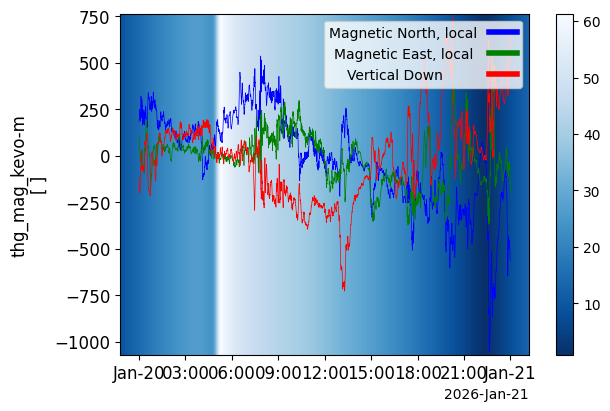

In [ ]:
fig, axs = plt.subplots(layout="constrained",figsize=(6,4))
ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a[0])
t = np.linspace(np.float64(20472.950000578705),np.float64(20474.049987847222),len(get_data("tha_pos_gsm").times))
ys = np.linspace(get_data('thg_mag_kevo-m').y.min(), get_data('thg_mag_kevo-m').y.max())
X,Y = np.meshgrid(t,ys)
Z = np.ones((len(ys),len(ang_sep_kevo_a)))
for i in range(Z.shape[0]):
    Z[i,:]=ang_sep_kevo_a
a_grad = axs.pcolormesh(X,Y,Z, vmin=np.min(Z), vmax=np.max(Z), shading='auto', cmap="Blues_r")
fig.colorbar(a_grad,ax=axs)
tplot(['thg_mag_kevo-m'],fig=fig,axis=axs)


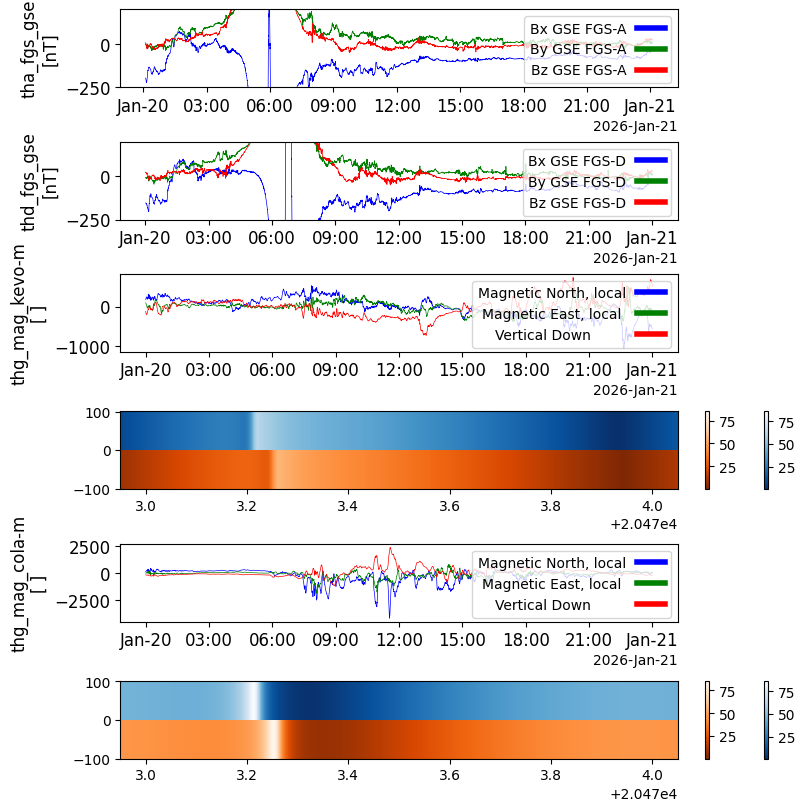

In [ ]:
from pyspedas.tplot_tools.MPLPlotter.tplot import tplot
from pyspedas.tplot_tools.get_data import get_data

def v_arr_dupe(y_dim,data):
    Z = np.ones((y_dim,len(data)))
    for i in range(Z.shape[0]):
        Z[i,:]=data
    return Z

fig, axs = plt.subplots(6,layout="constrained",figsize=(8,8))
axs[0].set_ylim(bottom=-250,top=200)
axs[1].set_ylim(bottom=-250,top=200)
ang_sep_kevo_a = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_a[0])
ang_sep_kevo_d = ang_sep(station_dict=station_location_dict["KEVO"],trace_data=trace_d[0])
ang_sep_cola_a = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_a[0])
ang_sep_cola_d = ang_sep(station_dict=station_location_dict["COLA"],trace_data=trace_d[0])

t = np.linspace(np.float64(20472.950000578705),np.float64(20474.049987847222),len(get_data("tha_pos_gsm").times))
n_y_pts = 50
ys = np.linspace(get_data('thg_mag_kevo-m').y.min(), get_data('thg_mag_kevo-m').y.max(),n_y_pts)

y_lower = np.linspace(-100, 0,n_y_pts)
y_upper = np.linspace(0, 100,n_y_pts)

Z_KEVO_A = v_arr_dupe(n_y_pts,ang_sep_kevo_a)
Z_KEVO_D = v_arr_dupe(n_y_pts,ang_sep_kevo_d)
Z_COLA_A = v_arr_dupe(n_y_pts,ang_sep_cola_a)
Z_COLA_D = v_arr_dupe(n_y_pts,ang_sep_cola_d)

#X,Y = np.meshgrid(t,ys)
X_L,Y_L = np.meshgrid(t,y_lower)
X_U,Y_U = np.meshgrid(t,y_upper)

a_min = np.min([np.min(Z_KEVO_A),np.min(Z_COLA_A)])
a_max = np.max([np.max(Z_KEVO_A),np.max(Z_COLA_A)])
d_min = np.min([np.min(Z_KEVO_D),np.min(Z_COLA_D)])
d_max = np.max([np.max(Z_KEVO_D),np.max(Z_COLA_D)])

kevo_a_grad = axs[3].pcolormesh(X_U,Y_U,Z_KEVO_A, vmin=a_min, vmax=a_max, shading='auto', cmap="Blues_r", alpha=1)
kevo_d_grad = axs[3].pcolormesh(X_L,Y_L,Z_KEVO_D, vmin=d_min, vmax=d_max, shading='auto', cmap="Oranges_r", alpha=1)
cola_a_grad = axs[5].pcolormesh(X_U,Y_U,Z_COLA_A, vmin=a_min, vmax=a_max, shading='auto', cmap="Blues_r", alpha=1)
cola_d_grad = axs[5].pcolormesh(X_L,Y_L,Z_COLA_D, vmin=d_min, vmax=d_max, shading='auto', cmap="Oranges_r", alpha=1)

fig.colorbar(kevo_a_grad,ax=axs[3])
fig.colorbar(kevo_d_grad,ax=axs[3])
fig.colorbar(cola_a_grad,ax=axs[5])
fig.colorbar(cola_d_grad,ax=axs[5])

tplot(['tha_fgs_gse','thd_fgs_gse','thg_mag_kevo-m','thg_mag_cola-m'],fig=fig,axis=[axs[0],axs[1],axs[2],axs[4]])
#fig.tight_layout()